In [ ]:
!pip install llama-index llama-index-llms-groq llama-index-embeddings-huggingface networkx matplotlib sentence-transformers

# --- Set GROQ_API_KEY as environment variable ---
import os
from google.colab import userdata

try:
    # Attempt to retrieve the API key from Colab secrets
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("GROQ_API_KEY loaded from Colab secrets.")
except userdata.SecretNotFoundError:
    print("GROQ_API_KEY not found in Colab secrets. Please enter it manually:")
    os.environ["GROQ_API_KEY"] = input("Enter your GROQ_API_KEY: ")

In [ ]:
import os
import json
import copy
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Optional, Dict, Any

from llama_index.core import Settings, VectorStoreIndex, PromptTemplate
from llama_index.core.schema import TextNode, NodeWithScore, QueryBundle
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.response_synthesizers import ResponseMode, get_response_synthesizer
from llama_index.core.postprocessor.types import BaseNodePostprocessor

# Integrations
from llama_index.llms.groq import Groq
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from sentence_transformers import CrossEncoder

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('KGRAG_DEMO')

In [ ]:
from pydantic import Field

# --- Mocking util.kg_post_processor ---

class KGRetrievePostProcessor(BaseNodePostprocessor):
    """
    Expands the retrieved context by looking up neighbors in the KG.
    Simulates fetching 'subgraphs' for retrieved entities.
    """
    doc2kg: Dict[str, Any] = Field(..., description="Mapping from document entity to KG relations")
    chunks_index: Dict[str, Any] = Field(..., description="Index for fast lookup of document chunks")
    initial_top_k: int = Field(5, description="Initial top-k for retrieval")

    def __init__(self, doc2kg: Dict[str, Any], chunks_index: Dict[str, Any], initial_top_k: int = 5, **kwargs: Any):
        super().__init__(doc2kg=doc2kg, chunks_index=chunks_index, initial_top_k=initial_top_k, **kwargs)

    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        all_nodes = copy.deepcopy(nodes)
        seen_entities = set()

        for node_with_score in nodes:
            node_text = node_with_score.node.text
            # Identify entities in the retrieved nodes
            # For simplicity, assume the title of the doc is the entity if it matches a KG key
            for entity, kg_facts in self.doc2kg.items():
                if entity in node_text and entity not in seen_entities:
                    logger.info(f"Found entity '{entity}' in retrieved node. Expanding KG...")
                    seen_entities.add(entity)
                    # Add KG facts as new nodes
                    for head, rel, tail in kg_facts:
                        kg_fact_str = f"KG Fact: {head} --[{rel}]--> {tail}"
                        kg_node = TextNode(text=kg_fact_str)
                        # Assign a default score or infer one if possible
                        # For now, let's assign a score similar to the original node, or slightly lower
                        all_nodes.append(NodeWithScore(node=kg_node, score=node_with_score.score * 0.9 if node_with_score.score else 0.5))

                    # Also add the full chunk text if it's not already there and relevant
                    if entity in self.chunks_index and self.chunks_index[entity] not in [n.node.text for n in all_nodes if n.node.text in self.chunks_index.values()]:
                        original_chunk_node = TextNode(text=self.chunks_index[entity])
                        all_nodes.append(NodeWithScore(node=original_chunk_node, score=node_with_score.score))

        return all_nodes

class GraphFilterPostProcessor(BaseNodePostprocessor):
    """
    Reranks and filters nodes using a CrossEncoder (acting as the FlagReranker).
    """
    reranker_model: str = Field(..., description="The name of the cross-encoder model to use for reranking.")
    top_k: int = Field(5, description="The number of top nodes to keep after reranking.")
    reranker: CrossEncoder = Field(..., description="The CrossEncoder model instance.")

    def __init__(self, reranker_model: str, top_k: int = 5, **kwargs: Any):
        _reranker_instance = CrossEncoder(reranker_model)
        super().__init__(reranker= _reranker_instance, reranker_model=reranker_model, top_k=top_k, **kwargs)

    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        if not nodes:
            return []

        query_text = query_bundle.query_str
        node_texts = [n.node.text for n in nodes]

        # Get scores
        scores = self.reranker.predict([(query_text, text) for text in node_texts])

        # Update scores
        for i, node in enumerate(nodes):
            node.score = float(scores[i])

        # Sort and slice
        nodes.sort(key=lambda x: x.score, reverse=True)
        return nodes[:self.top_k]

class ImprovedPostProcessor(BaseNodePostprocessor):
    """Simple pass-through to track nodes, as per your modified2.py"""
    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        # In a real app, you might log usage here
        return nodes

In [ ]:
def generate_education_data():
    """
    Generates a synthetic dataset for the Education domain.
    Returns:
        documents: List of dicts (mocking the json file)
        kg: Dict (mocking the sub-KG json files)
    """

    # 1. The Corpus (Text Data)
    documents = [
        {
            "id": "doc_1",
            "title": "Dr. Sarah Chen",
            "text": "Dr. Sarah Chen is a Senior Professor at Stanford University. She specializes in Deep Learning and Natural Language Processing. She is the primary instructor for the course CS224n."
        },
        {
            "id": "doc_2",
            "title": "CS224n",
            "text": "CS224n is a graduate-level course titled 'Natural Language Processing with Deep Learning'. The course covers topic such as Transformers, Attention Mechanisms, and Word Embeddings. The final exam accounts for 40% of the grade."
        },
        {
            "id": "doc_3",
            "title": "Transformers",
            "text": "Transformers are a deep learning architecture introduced in the paper 'Attention is All You Need'. They rely entirely on self-attention mechanisms to compute representations of input and output without using sequence-aligned RNNs."
        }
    ]

    # 2. The Knowledge Graph (KG) - Triplet format
    # Structure: Entity -> [ [Head, Relation, Tail], ... ]
    kg = {
        "Dr. Sarah Chen": [
            ["Dr. Sarah Chen", "teaches", "CS224n"],
            ["Dr. Sarah Chen", "works_at", "Stanford University"]
        ],
        "CS224n": [
            ["CS224n", "covers_topic", "Transformers"],
            ["CS224n", "covers_topic", "Attention Mechanisms"],
            ["CS224n", "taught_by", "Dr. Sarah Chen"]
        ],
        "Transformers": [
            ["Transformers", "introduced_in", "Attention is All You Need"],
            ["Transformers", "uses", "Self-Attention"]
        ]
    }

    return documents, kg

def visualize_kg_response(subgraph_nodes):
    """Visualizes the KG part of the retrieved context"""
    G = nx.DiGraph()

    for node in subgraph_nodes:
        text = node.node.text
        if "KG Fact:" in text:
            # Parse "KG Fact: Head --[Rel]--> Tail"
            try:
                parts = text.replace("KG Fact: ", "").split("--[")
                head = parts[0].strip()
                rest = parts[1].split("]-->")
                rel = rest[0]
                tail = rest[1].strip()
                G.add_edge(head, tail, label=rel)
            except:
                continue

    if G.number_of_nodes() == 0:
        print("No KG connections found to visualize.")
        return

    pos = nx.spring_layout(G)
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Retrieved Knowledge Graph Subgraph")
    plt.show()

In [ ]:
def run_kgrag_pipeline():
    # --- 1. Init Models ---
    print("Initializing Models...")

    # LLM: Groq
    llm = Groq(model="llama-3.1-8b-instant", api_key=os.environ.get("GROQ_API_KEY"))

    # Embedding: HuggingFace (Runs on Colab GPU/CPU)
    embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")

    # Reranker Model Name (Using a small cross-encoder for the demo)
    reranker_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"

    Settings.llm = llm
    Settings.embed_model = embed_model

    # --- 2. Load Data ---
    docs, kg = generate_education_data()
    print(f"Loaded {len(docs)} documents and KG for {len(kg)} entities.")

    # --- 3. Indexing ---
    # Convert docs to TextNodes
    nodes = []
    chunks_index = {} # For fast lookup

    print("Indexing Data...")
    for doc in docs:
        text = f"{doc['title']}: {doc['text']}"
        node = TextNode(text=text, id_=doc['id'])
        nodes.append(node)
        chunks_index[doc['title']] = text

    # Build Vector Index
    index = VectorStoreIndex(nodes)
    retriever = VectorIndexRetriever(index=index, similarity_top_k=5)

    # --- 4. Define PostProcessors ---

    # Expansion (KG Retrieval)
    expansion_pp = KGRetrievePostProcessor(
        doc2kg=kg,
        chunks_index=chunks_index
    )

    # Filtering (Reranker)
    filter_pp = GraphFilterPostProcessor(
        reranker_model=reranker_name,
        top_k=3 # Final Top K
    )

    # Tracking
    naive_pp = ImprovedPostProcessor()

    # --- 5. Setup Query Engine ---

    # Prompt Template (from your code)
    qa_template_str = '''Context information is below.
{context_str}

Instructions: Answer the question based ONLY on the context provided above. Think step by step to identify the key facts needed. Give a short factoid answer.

Q: {query_str}
A: '''
    qa_prompt = PromptTemplate(qa_template_str)

    response_synthesizer = get_response_synthesizer(
        response_mode=ResponseMode.COMPACT,
        text_qa_template=qa_prompt
    )

    query_engine = RetrieverQueryEngine(
        retriever=retriever,
        response_synthesizer=response_synthesizer,
        node_postprocessors=[expansion_pp, filter_pp, naive_pp]
    )

    return query_engine

Initializing Models...
Loaded 3 documents and KG for 3 entities.
Indexing Data...

QUESTION: What architecture does the course taught by Dr. Sarah Chen cover?

ANSWER: To answer the question, we need to identify the key facts from the context provided. 

1. Dr. Sarah Chen is a Senior Professor at Stanford University.
2. She specializes in Deep Learning and Natural Language Processing.
3. The course CS224n is taught by Dr. Sarah Chen.

Since Dr. Sarah Chen specializes in Deep Learning and Natural Language Processing, and she is the instructor for the course CS224n, we can infer that the course CS224n likely covers these topics.

Factoid answer: The course CS224n, taught by Dr. Sarah Chen, covers Deep Learning and Natural Language Processing.

-------------------- SUPPORTING FACTS (Retrieved Nodes) --------------------
[Score: 4.3700] Dr. Sarah Chen: Dr. Sarah Chen is a Senior Professor at Stanford University. She specializes in Deep...
[Score: 1.3166] KG Fact: Dr. Sarah Chen --[teaches]

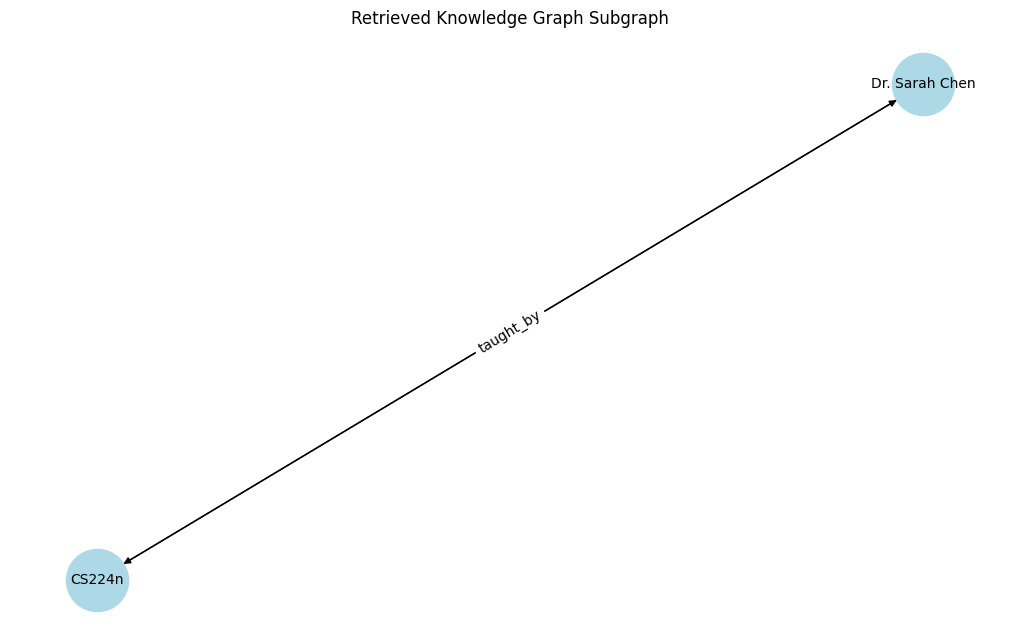

In [ ]:
# --- MAIN EXECUTION ---

# 1. Build Pipeline
engine = run_kgrag_pipeline()

# 2. Define a Question related to the Education Data
question = "What architecture does the course taught by Dr. Sarah Chen cover?"

print(f"\n{'='*50}")
print(f"QUESTION: {question}")
print(f"{'='*50}\n")

# 3. Run Query
response = engine.query(question)

# 4. Output Results
print(f"ANSWER: {response.response}\n")

print(f"{'-'*20} SUPPORTING FACTS (Retrieved Nodes) {'-'*20}")
for node in response.source_nodes:
    print(f"[Score: {node.score:.4f}] {node.node.text[:100]}...")

# 5. Visualize the KG logic
print("\nGenerating Visuals...")
visualize_kg_response(response.source_nodes)

Testing

In [ ]:
!pip install llama-index llama-index-llms-groq llama-index-embeddings-huggingface networkx matplotlib sentence-transformers

# --- Set GROQ_API_KEY as environment variable ---
import os
from google.colab import userdata

try:
    # Attempt to retrieve the API key from Colab secrets
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
    print("GROQ_API_KEY loaded from Colab secrets.")
except userdata.SecretNotFoundError:
    print("GROQ_API_KEY not found in Colab secrets. Please enter it manually:")
    os.environ["GROQ_API_KEY"] = input("Enter your GROQ_API_KEY: ")

GROQ_API_KEY not found in Colab secrets. Please enter it manually:
Enter your GROQ_API_KEY: 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


In [ ]:
import os
import json
import copy
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Optional, Dict, Any

from llama_index.core import Settings, VectorStoreIndex, PromptTemplate
from llama_index.core.schema import TextNode, NodeWithScore, QueryBundle
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.response_synthesizers import ResponseMode, get_response_synthesizer
from llama_index.core.postprocessor.types import BaseNodePostprocessor

# Integrations
from llama_index.llms.groq import Groq
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from sentence_transformers import CrossEncoder

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('KGRAG_DEMO')

In [ ]:
from pydantic import Field

# --- Mocking util.kg_post_processor ---

class KGRetrievePostProcessor(BaseNodePostprocessor):
    """
    Expands the retrieved context by looking up neighbors in the KG.
    Simulates fetching 'subgraphs' for retrieved entities.
    """
    doc2kg: Dict[str, Any] = Field(..., description="Mapping from document entity to KG relations")
    chunks_index: Dict[str, Any] = Field(..., description="Index for fast lookup of document chunks")
    initial_top_k: int = Field(5, description="Initial top-k for retrieval")

    def __init__(self, doc2kg: Dict[str, Any], chunks_index: Dict[str, Any], initial_top_k: int = 5, **kwargs: Any):
        super().__init__(doc2kg=doc2kg, chunks_index=chunks_index, initial_top_k=initial_top_k, **kwargs)

    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        all_nodes = copy.deepcopy(nodes)
        seen_entities = set()

        for node_with_score in nodes:
            node_text = node_with_score.node.text
            # Identify entities in the retrieved nodes
            # For simplicity, assume the title of the doc is the entity if it matches a KG key
            for entity, kg_facts in self.doc2kg.items():
                if entity in node_text and entity not in seen_entities:
                    logger.info(f"Found entity '{entity}' in retrieved node. Expanding KG...")
                    seen_entities.add(entity)
                    # Add KG facts as new nodes
                    for head, rel, tail in kg_facts:
                        kg_fact_str = f"KG Fact: {head} --[{rel}]--> {tail}"
                        kg_node = TextNode(text=kg_fact_str)
                        # Assign a default score or infer one if possible
                        # For now, let's assign a score similar to the original node, or slightly lower
                        all_nodes.append(NodeWithScore(node=kg_node, score=node_with_score.score * 0.9 if node_with_score.score else 0.5))

                    # Also add the full chunk text if it's not already there and relevant
                    if entity in self.chunks_index and self.chunks_index[entity] not in [n.node.text for n in all_nodes if n.node.text in self.chunks_index.values()]:
                        original_chunk_node = TextNode(text=self.chunks_index[entity])
                        all_nodes.append(NodeWithScore(node=original_chunk_node, score=node_with_score.score))

        return all_nodes

class GraphFilterPostProcessor(BaseNodePostprocessor):
    """
    Reranks and filters nodes using a CrossEncoder (acting as the FlagReranker).
    """
    reranker_model: str = Field(..., description="The name of the cross-encoder model to use for reranking.")
    top_k: int = Field(5, description="The number of top nodes to keep after reranking.")
    reranker: CrossEncoder = Field(..., description="The CrossEncoder model instance.")

    def __init__(self, reranker_model: str, top_k: int = 5, **kwargs: Any):
        _reranker_instance = CrossEncoder(reranker_model)
        super().__init__(reranker= _reranker_instance, reranker_model=reranker_model, top_k=top_k, **kwargs)

    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        if not nodes:
            return []

        query_text = query_bundle.query_str
        node_texts = [n.node.text for n in nodes]

        # Get scores
        scores = self.reranker.predict([(query_text, text) for text in node_texts])

        # Update scores
        for i, node in enumerate(nodes):
            node.score = float(scores[i])

        # Sort and slice
        nodes.sort(key=lambda x: x.score, reverse=True)
        return nodes[:self.top_k]

class ImprovedPostProcessor(BaseNodePostprocessor):
    """Simple pass-through to track nodes, as per your modified2.py"""
    def _postprocess_nodes(self, nodes: List[NodeWithScore], query_bundle: Optional[QueryBundle] = None) -> List[NodeWithScore]:
        # In a real app, you might log usage here
        return nodes

In [ ]:
def generate_education_data():
    """
    Generates a synthetic dataset for the Education domain.
    Extended with more entities to support 3-hop queries.
    Returns:
        documents: List of dicts (mocking the json file)
        kg: Dict (mocking the sub-KG json files)
    """

    # 1. The Corpus (Text Data) - Extended
    documents = [
        {
            "id": "doc_1",
            "title": "Dr. Sarah Chen",
            "text": "Dr. Sarah Chen is a Senior Professor at Stanford University. She specializes in Deep Learning and Natural Language Processing. She is the primary instructor for the course CS224n. She earned her PhD from MIT."
        },
        {
            "id": "doc_2",
            "title": "CS224n",
            "text": "CS224n is a graduate-level course titled 'Natural Language Processing with Deep Learning'. The course covers topics such as Transformers, Attention Mechanisms, and Word Embeddings. The final exam accounts for 40% of the grade. The course uses materials from the 'Attention is All You Need' paper."
        },
        {
            "id": "doc_3",
            "title": "Transformers",
            "text": "Transformers are a deep learning architecture introduced in the paper 'Attention is All You Need'. They rely entirely on self-attention mechanisms to compute representations of input and output without using sequence-aligned RNNs."
        },
        {
            "id": "doc_4",
            "title": "Attention is All You Need",
            "text": "Attention is All You Need is a landmark paper published in 2017 by Vaswani et al. It introduced the Transformer architecture and the self-attention mechanism. The paper was presented at NeurIPS and became highly influential in the field of NLP."
        },
        {
            "id": "doc_5",
            "title": "Stanford University",
            "text": "Stanford University is a leading research institution located in California. The Computer Science department is known for its excellence in AI and Machine Learning research. It hosts the Stanford AI Lab and other research centers."
        },
        {
            "id": "doc_6",
            "title": "Self-Attention Mechanism",
            "text": "Self-Attention is a mechanism that allows a model to pay attention to different parts of the input. It is the core component of the Transformer architecture. Self-Attention computes weighted sums of input features using learnable query, key, and value vectors."
        },
        {
            "id": "doc_7",
            "title": "NeurIPS Conference",
            "text": "NeurIPS is the Neural Information Processing Systems conference, one of the most prestigious conferences in machine learning. Major breakthroughs like the Transformer architecture have been published at NeurIPS."
        }
    ]

    # 2. The Knowledge Graph (KG) - Extended Triplet format
    # Structure: Entity -> [ [Head, Relation, Tail], ... ]
    kg = {
        "Dr. Sarah Chen": [
            ["Dr. Sarah Chen", "teaches", "CS224n"],
            ["Dr. Sarah Chen", "works_at", "Stanford University"],
            ["Dr. Sarah Chen", "graduated_from", "MIT"],
            ["Dr. Sarah Chen", "specializes_in", "Natural Language Processing"]
        ],
        "CS224n": [
            ["CS224n", "covers_topic", "Transformers"],
            ["CS224n", "covers_topic", "Attention Mechanisms"],
            ["CS224n", "covers_topic", "Word Embeddings"],
            ["CS224n", "taught_by", "Dr. Sarah Chen"],
            ["CS224n", "uses_paper", "Attention is All You Need"],
            ["CS224n", "offered_at", "Stanford University"]
        ],
        "Transformers": [
            ["Transformers", "introduced_in", "Attention is All You Need"],
            ["Transformers", "uses", "Self-Attention Mechanism"],
            ["Transformers", "published_at", "NeurIPS Conference"],
            ["Transformers", "is_part_of", "Deep Learning"]
        ],
        "Attention is All You Need": [
            ["Attention is All You Need", "published_year", "2017"],
            ["Attention is All You Need", "authored_by", "Vaswani et al."],
            ["Attention is All You Need", "presented_at", "NeurIPS Conference"],
            ["Attention is All You Need", "introduces", "Transformers"],
            ["Attention is All You Need", "introduces", "Self-Attention Mechanism"]
        ],
        "Stanford University": [
            ["Stanford University", "location", "California"],
            ["Stanford University", "hosts_faculty", "Dr. Sarah Chen"],
            ["Stanford University", "offers_course", "CS224n"],
            ["Stanford University", "department", "Computer Science"]
        ],
        "Self-Attention Mechanism": [
            ["Self-Attention Mechanism", "core_of", "Transformers"],
            ["Self-Attention Mechanism", "introduced_in", "Attention is All You Need"],
            ["Self-Attention Mechanism", "taught_in", "CS224n"]
        ],
        "NeurIPS Conference": [
            ["NeurIPS Conference", "published", "Attention is All You Need"],
            ["NeurIPS Conference", "prestigious", "true"],
            ["NeurIPS Conference", "field", "Machine Learning"]
        ]
    }

    return documents, kg

def display_full_kg(kg):
    """Displays the entire Knowledge Graph in a structured format"""
    print("\n" + "="*80)
    print("FULL KNOWLEDGE GRAPH")
    print("="*80)
    for entity, facts in kg.items():
        print(f"\nEntity: {entity}")
        for head, rel, tail in facts:
            print(f"  → {head} --[{rel}]--> {tail}")
    print("\n" + "="*80 + "\n")

def visualize_kg_response(subgraph_nodes):
    """Visualizes the KG part of the retrieved context"""
    G = nx.DiGraph()

    for node in subgraph_nodes:
        text = node.node.text
        if "KG Fact:" in text:
            # Parse "KG Fact: Head --[Rel]--> Tail"
            try:
                parts = text.replace("KG Fact: ", "").split("--[")
                head = parts[0].strip()
                rest = parts[1].split("]-->")
                rel = rest[0]
                tail = rest[1].strip()
                G.add_edge(head, tail, label=rel)
            except:
                continue

    if G.number_of_nodes() == 0:
        print("No KG connections found to visualize.")
        return

    pos = nx.spring_layout(G)
    plt.figure(figsize=(10, 6))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10, arrows=True)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title("Retrieved Knowledge Graph Subgraph")
    plt.show()


In [ ]:
def run_kgrag_pipeline():
    # --- 1. Init Models ---
    print("Initializing Models...")

    # LLM: Groq
    llm = Groq(model="llama-3.1-8b-instant", api_key=os.environ.get("GROQ_API_KEY"))

    # Embedding: HuggingFace (Runs on Colab GPU/CPU)
    embed_model = HuggingFaceEmbedding(model_name="BAAI/bge-small-en-v1.5")

    # Reranker Model Name (Using a small cross-encoder for the demo)
    reranker_name = "cross-encoder/ms-marco-MiniLM-L-6-v2"

    Settings.llm = llm
    Settings.embed_model = embed_model

    # --- 2. Load Data ---
    docs, kg = generate_education_data()
    print(f"Loaded {len(docs)} documents and KG for {len(kg)} entities.")

    # --- 3. Indexing ---
    # Convert docs to TextNodes
    nodes = []
    chunks_index = {} # For fast lookup

    print("Indexing Data...")
    for doc in docs:
        text = f"{doc['title']}: {doc['text']}"
        node = TextNode(text=text, id_=doc['id'])
        nodes.append(node)
        chunks_index[doc['title']] = text

    # Build Vector Index
    index = VectorStoreIndex(nodes)
    retriever = VectorIndexRetriever(index=index, similarity_top_k=5)

    # --- 4. Define PostProcessors ---

    # Expansion (KG Retrieval)
    expansion_pp = KGRetrievePostProcessor(
        doc2kg=kg,
        chunks_index=chunks_index
    )

    # Filtering (Reranker)
    filter_pp = GraphFilterPostProcessor(
        reranker_model=reranker_name,
        top_k=3 # Final Top K
    )

    # Tracking
    naive_pp = ImprovedPostProcessor()

    # --- 5. Setup Query Engine ---

    # Prompt Template (from your code)
    qa_template_str = '''Context information is below.
{context_str}

Instructions: Answer the question based ONLY on the context provided above. Think step by step to identify the key facts needed. Give a short factoid answer.

Q: {query_str}
A: '''
    qa_prompt = PromptTemplate(qa_template_str)

    response_synthesizer = get_response_synthesizer(
        response_mode=ResponseMode.COMPACT,
        text_qa_template=qa_prompt
    )

    query_engine = RetrieverQueryEngine(
        retriever=retriever,
        response_synthesizer=response_synthesizer,
        node_postprocessors=[expansion_pp, filter_pp, naive_pp]
    )

    return query_engine

Initializing Models...
Loaded 7 documents and KG for 7 entities.
Indexing Data...

FULL KNOWLEDGE GRAPH

Entity: Dr. Sarah Chen
  → Dr. Sarah Chen --[teaches]--> CS224n
  → Dr. Sarah Chen --[works_at]--> Stanford University
  → Dr. Sarah Chen --[graduated_from]--> MIT
  → Dr. Sarah Chen --[specializes_in]--> Natural Language Processing

Entity: CS224n
  → CS224n --[covers_topic]--> Transformers
  → CS224n --[covers_topic]--> Attention Mechanisms
  → CS224n --[covers_topic]--> Word Embeddings
  → CS224n --[taught_by]--> Dr. Sarah Chen
  → CS224n --[uses_paper]--> Attention is All You Need
  → CS224n --[offered_at]--> Stanford University

Entity: Transformers
  → Transformers --[introduced_in]--> Attention is All You Need
  → Transformers --[uses]--> Self-Attention Mechanism
  → Transformers --[published_at]--> NeurIPS Conference
  → Transformers --[is_part_of]--> Deep Learning

Entity: Attention is All You Need
  → Attention is All You Need --[published_year]--> 2017
  → Attention is Al

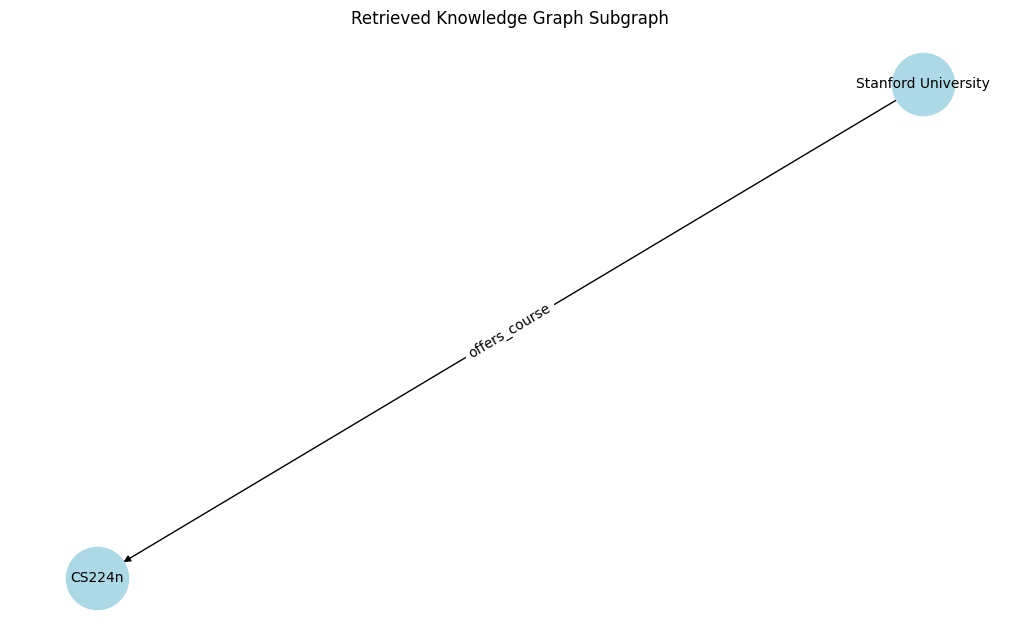

In [ ]:
# --- MAIN EXECUTION ---

# 1. Build Pipeline
engine = run_kgrag_pipeline()

# 2. Display the full KG
docs, kg = generate_education_data()
display_full_kg(kg)

# 3. Define a 3-HOP Question related to the Education Data
# Query path: Dr. Sarah Chen -> works_at -> Stanford University -> hosts_faculty -> ... -> Computer Science
question = "What prestigious conference published the paper on the architecture covered in the course taught by the professor at Stanford University?"

print(f"\n{'='*80}")
print(f"QUESTION (3-HOP QUERY): {question}")
print(f"{'='*80}\n")

# 4. Run Query
response = engine.query(question)

# 5. Output Results
print(f"\nANSWER: {response.response}\n")

# 6. Display Retrieved Semantic Chunks
print(f"\n{'-'*80} SEMANTIC CHUNKS RETRIEVED {'-'*80}")
semantic_chunks = []
kg_nodes = []

for i, node in enumerate(response.source_nodes, 1):
    node_text = node.node.text
    # Separate semantic chunks from KG facts
    if "KG Fact:" in node_text:
        kg_nodes.append((i, node.score, node_text))
    else:
        semantic_chunks.append((i, node.score, node_text))

print("\nSemantic Document Chunks:")
for idx, score, text in semantic_chunks:
    print(f"\n[{idx}] Score: {score:.4f}")
    print(f"    {text}")

# 7. Display KG Nodes Used
print(f"\n{'-'*80} KNOWLEDGE GRAPH NODES USED FOR CONTEXT {'-'*80}")
print("\nKG Facts Retrieved:")
for idx, score, text in kg_nodes:
    print(f"\n[{idx}] Score: {score:.4f}")
    print(f"    {text}")

if not kg_nodes:
    print("No KG facts were retrieved in this context window.")

# 8. Summary Statistics
print(f"\n{'-'*80} RETRIEVAL SUMMARY {'-'*80}")
print(f"Total nodes retrieved: {len(response.source_nodes)}")
print(f"Semantic chunks: {len(semantic_chunks)}")
print(f"KG nodes: {len(kg_nodes)}")
print(f"Average score: {sum(n.score for n in response.source_nodes) / len(response.source_nodes):.4f}")

# 9. Visualize the KG logic
print(f"\n{'-'*80} VISUALIZING RETRIEVED KG SUBGRAPH {'-'*80}\n")
visualize_kg_response(response.source_nodes)
